# **Stock Price Prediction using LSTM(Long Short Term Memory)**

**Importing the dependencies**

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

**---- INITIAL DATA ANALYSIS & PRE PROCESSING ----**

**Reading the file and Initial Data Analysis**

In [ ]:
dataset = pd.read_csv("/Users/anilreddyperugu/Git/DL-Projects/08. Stock Price Prediction using LSTM/dataset.csv") #reading the datset

In [3]:
print(dataset)

            Date    Open    High     Low   Close    Volume Name
0     2006-01-03   82.45   82.55   80.81   82.06  11715200  IBM
1     2006-01-04   82.20   82.50   81.33   81.95   9840600  IBM
2     2006-01-05   81.40   82.90   81.00   82.50   7213500  IBM
3     2006-01-06   83.95   85.03   83.41   84.95   8197400  IBM
4     2006-01-09   84.10   84.25   83.38   83.73   6858200  IBM
...          ...     ...     ...     ...     ...       ...  ...
3015  2017-12-22  151.82  153.00  151.50  152.50   2990583  IBM
3016  2017-12-26  152.51  153.86  152.50  152.83   2479017  IBM
3017  2017-12-27  152.95  153.18  152.61  153.13   2149257  IBM
3018  2017-12-28  153.20  154.12  153.20  154.04   2687624  IBM
3019  2017-12-29  154.17  154.72  153.42  153.42   3327087  IBM

[3020 rows x 7 columns]


In [ ]:
dataset.shape #dimensions of the dataset

(3020, 7)

In [ ]:
dataset.info() #information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3020 entries, 0 to 3019
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3020 non-null   object 
 1   Open    3019 non-null   float64
 2   High    3020 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3020 non-null   float64
 5   Volume  3020 non-null   int64  
 6   Name    3020 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 165.3+ KB


In [ ]:
dataset.describe #statistical description of the data

<bound method NDFrame.describe of             Date    Open    High     Low   Close    Volume Name
0     2006-01-03   82.45   82.55   80.81   82.06  11715200  IBM
1     2006-01-04   82.20   82.50   81.33   81.95   9840600  IBM
2     2006-01-05   81.40   82.90   81.00   82.50   7213500  IBM
3     2006-01-06   83.95   85.03   83.41   84.95   8197400  IBM
4     2006-01-09   84.10   84.25   83.38   83.73   6858200  IBM
...          ...     ...     ...     ...     ...       ...  ...
3015  2017-12-22  151.82  153.00  151.50  152.50   2990583  IBM
3016  2017-12-26  152.51  153.86  152.50  152.83   2479017  IBM
3017  2017-12-27  152.95  153.18  152.61  153.13   2149257  IBM
3018  2017-12-28  153.20  154.12  153.20  154.04   2687624  IBM
3019  2017-12-29  154.17  154.72  153.42  153.42   3327087  IBM

[3020 rows x 7 columns]>

**Handling null values**

In [ ]:
dataset.isnull().sum() #checking null values

Date      0
Open      1
High      0
Low       1
Close     0
Volume    0
Name      0
dtype: int64

In [ ]:
df = dataset.dropna() #dropping null values

In [9]:
print(df.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Name      0
dtype: int64


**Forming the DataFrame into required format**

In [ ]:
df = df.sort_values("Date") #sorting the data using date

In [28]:
df

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
1,2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2,2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
3,2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
4,2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM
...,...,...,...,...,...,...,...
3015,2017-12-22,151.82,153.00,151.50,152.50,2990583,IBM
3016,2017-12-26,152.51,153.86,152.50,152.83,2479017,IBM
3017,2017-12-27,152.95,153.18,152.61,153.13,2149257,IBM
3018,2017-12-28,153.20,154.12,153.20,154.04,2687624,IBM


**Choosing the most important feature for the training**

In [ ]:
data = df[['Close']] 

In [30]:
data

,Close
0,82.06
1,81.95
2,82.50
3,84.95
4,83.73
...,...
3015,152.50
3016,152.83
3017,153.13
3018,154.04


**----- BUILDING A MODEL -----**

**Splitting the data for training and testing**

In [ ]:
train_data=data.iloc[:2399] #first 2399 rows training
test_data=data.iloc[2399:] #remaining rows for test

In [ ]:
print(train_data.shape) #finding dimensions of the splitted data
print(test_data.shape)

(2399, 1)
(620, 1)


**Scaling the data with Min-Max Scalar**

In [ ]:
mm_scalar = MinMaxScaler() #Intializing the Scalar
train_transformed = mm_scalar.fit_transform(train_data) #transforming the data
test_transformed = mm_scalar.transform(test_data)

**Preparing Time Series Sequences for LSTM Model**

In [ ]:
X = []
Y = []

window_size = 60

for i in range(window_size, len(train_transformed)): 
    X.append(train_transformed[i-window_size:i]) #picking a sequence of 60 everytime
    Y.append(train_transformed[i])

X_train = np.array(X) #transforming them into arrays
Y_train = np.array(Y)

In [ ]:
print(X_train.shape) #finding dimensions of the above operation data
print(Y_train.shape)

(2339, 60, 1)
(2339, 1)


**Preparing Time Series Sequences for LSTM Model on test data**

In [ ]:
X_test = []
Y_test = []

window_size = 60

for i in range(window_size, len(test_transformed)):
    X_test.append(test_transformed[i-window_size:i]) #picking a sequence of 60 everytime
    Y_test.append(test_transformed[i])

X_test=np.array(X_test) #transforming them into arrays
Y_test=np.array(Y_test)

In [ ]:
print(X_test.shape) #finding dimensions for the above operation data
print(Y_test.shape)

(560, 60, 1)
(560, 1)


**Building a Sequential Model**

In [59]:
model = Sequential()
model.add(LSTM(units=64, input_shape=(60,1)))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

**Training the model**

In [91]:
history = model.fit(X_train, Y_train,
                    epochs=50,
                    verbose=1,
                    batch_size=32,
                    validation_data=(X_test, Y_test))

Epoch 1/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0019 - val_loss: 4.8517e-04
Epoch 2/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 3/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0020 - val_loss: 3.5783e-04
Epoch 4/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0018 - val_loss: 4.0310e-04
Epoch 5/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0018 - val_loss: 3.7333e-04
Epoch 6/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0018 - val_loss: 3.5399e-04
Epoch 7/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0015 - val_loss: 3.5949e-04
Epoch 8/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0016 - val_loss: 6.7021e-04
Epoch 9/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0015 - val_loss: 4.7479e-04
Epoch 10/50
74/74 [==============================] - 1s 10ms/step - loss: 0.0

**Predicting using the trained model**

In [92]:
results = model.predict(X_test)

18/18 [==============================] - 0s 3ms/step


**Prediction results**

In [93]:
results.shape

(560, 1)

In [94]:
print(results)


[[0.5522311 ]
 [0.56032944]
 [0.5615942 ]
 [0.5566113 ]
 [0.55210614]
 [0.54903203]
 [0.54819584]
 [0.5456843 ]
 [0.5234107 ]
 [0.50432694]
 [0.4989243 ]
 [0.50047696]
 [0.50203025]
 [0.4900964 ]
 [0.48577726]
 [0.4832781 ]
 [0.48125926]
 [0.48091996]
 [0.48474738]
 [0.48786315]
 [0.48586446]
 [0.47926235]
 [0.46636268]
 [0.4561383 ]
 [0.44854805]
 [0.4397719 ]
 [0.4309589 ]
 [0.42967898]
 [0.43108898]
 [0.43793914]
 [0.44635594]
 [0.45684636]
 [0.46431836]
 [0.46881074]
 [0.46923625]
 [0.4691488 ]
 [0.47081968]
 [0.47668082]
 [0.47808993]
 [0.4763745 ]
 [0.4777546 ]
 [0.47714788]
 [0.47288406]
 [0.46566615]
 [0.46028295]
 [0.45183286]
 [0.4487582 ]
 [0.45237207]
 [0.4604573 ]
 [0.46160552]
 [0.4565904 ]
 [0.45254606]
 [0.45519117]
 [0.460077  ]
 [0.46371937]
 [0.46456677]
 [0.46941832]
 [0.47238523]
 [0.46999758]
 [0.4629852 ]
 [0.4564932 ]
 [0.45036632]
 [0.44105077]
 [0.43130177]
 [0.42829704]
 [0.42730477]
 [0.42368928]
 [0.42489994]
 [0.42012745]
 [0.4112087 ]
 [0.3894444 ]
 [0.37

**Back transformed the scaled data into stock prices**

In [95]:
results_transformed = mm_scalar.inverse_transform(results)
print(results_transformed)

[[151.2944  ]
 [152.46106 ]
 [152.64326 ]
 [151.92542 ]
 [151.27641 ]
 [150.83356 ]
 [150.71309 ]
 [150.35129 ]
 [147.14253 ]
 [144.39334 ]
 [143.61504 ]
 [143.83871 ]
 [144.06247 ]
 [142.34329 ]
 [141.72107 ]
 [141.36104 ]
 [141.0702  ]
 [141.02133 ]
 [141.57271 ]
 [142.02156 ]
 [141.73364 ]
 [140.78253 ]
 [138.92421 ]
 [137.4513  ]
 [136.35783 ]
 [135.09354 ]
 [133.82394 ]
 [133.63956 ]
 [133.84268 ]
 [134.82951 ]
 [136.04204 ]
 [137.55328 ]
 [138.6297  ]
 [139.27687 ]
 [139.33818 ]
 [139.32558 ]
 [139.56628 ]
 [140.41064 ]
 [140.61363 ]
 [140.36652 ]
 [140.56532 ]
 [140.47792 ]
 [139.86368 ]
 [138.82387 ]
 [138.04836 ]
 [136.83104 ]
 [136.3881  ]
 [136.90872 ]
 [138.07347 ]
 [138.23889 ]
 [137.51642 ]
 [136.93379 ]
 [137.31483 ]
 [138.01869 ]
 [138.54341 ]
 [138.6655  ]
 [139.3644  ]
 [139.79182 ]
 [139.44786 ]
 [138.43765 ]
 [137.50241 ]
 [136.61978 ]
 [135.27777 ]
 [133.87334 ]
 [133.44048 ]
 [133.29753 ]
 [132.77667 ]
 [132.9511  ]
 [132.26357 ]
 [130.97873 ]
 [127.84337 ]
 [125.

In [96]:
y_test_back_transformed = mm_scalar.inverse_transform(Y_test)
print(y_test_back_transformed)

[[152.39]
 [151.14]
 [149.62]
 [150.01]
 [150.09]
 [150.39]
 [149.22]
 [140.64]
 [140.92]
 [144.09]
 [144.68]
 [143.66]
 [137.86]
 [140.83]
 [140.55]
 [140.08]
 [140.37]
 [141.88]
 [141.63]
 [139.89]
 [138.25]
 [135.31]
 [135.47]
 [135.02]
 [133.04]
 [131.75]
 [133.71]
 [133.82]
 [135.82]
 [136.74]
 [138.5 ]
 [138.46]
 [138.6 ]
 [138.  ]
 [138.46]
 [139.42]
 [141.28]
 [139.7 ]
 [138.92]
 [140.43]
 [139.55]
 [138.05]
 [136.61]
 [136.78]
 [134.57]
 [135.93]
 [137.79]
 [139.29]
 [136.75]
 [134.9 ]
 [135.5 ]
 [137.93]
 [138.54]
 [138.25]
 [137.61]
 [139.78]
 [139.34]
 [137.62]
 [135.95]
 [135.85]
 [135.17]
 [132.86]
 [131.63]
 [133.23]
 [132.9 ]
 [131.17]
 [132.91]
 [130.03]
 [128.11]
 [121.86]
 [122.91]
 [122.5 ]
 [122.08]
 [122.59]
 [120.96]
 [122.22]
 [124.79]
 [124.83]
 [122.94]
 [124.72]
 [127.65]
 [128.57]
 [126.98]
 [124.07]
 [120.19]
 [117.85]
 [121.04]
 [122.74]
 [126.1 ]
 [132.45]
 [133.08]
 [133.77]
 [132.4 ]
 [132.8 ]
 [134.5 ]
 [132.03]
 [131.03]
 [134.37]
 [136.3 ]
 [137.8 ]


**---- VISUALIZATON ----**  

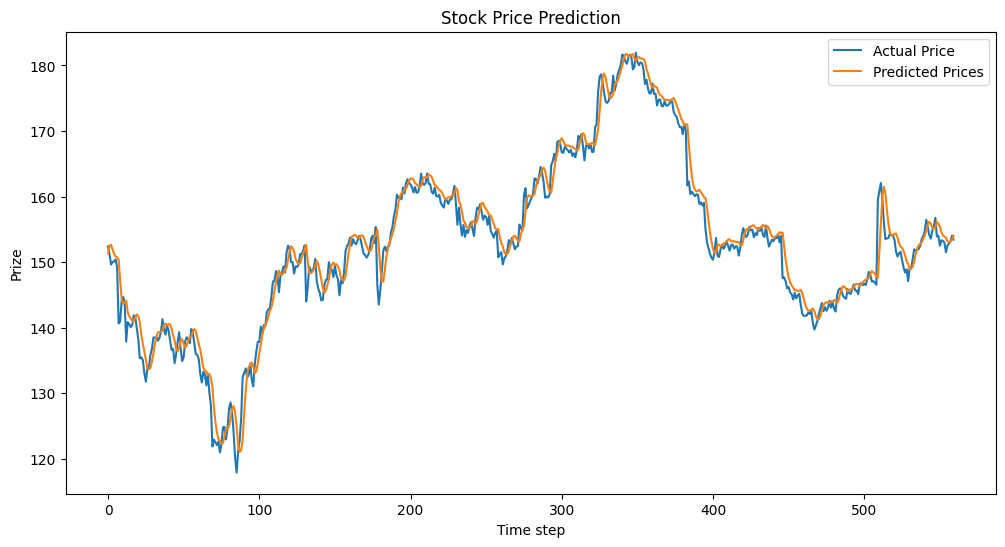

In [ ]:
plt.figure(figsize=(12,6)) #Initializing em empty figure

plt.plot(y_test_back_transformed, label='Actual Price') #plotting the actual data
plt.plot(results_transformed, label = 'Predicted Prices') #plotting the predicted data

plt.title('Stock Price Prediction') #Title for the graph
plt.xlabel('Time step') # X label
plt.ylabel('Prize') # Y label
plt.legend() #Indicator
plt.show() #showing the plot


**----- MODEL EVALUATION ----**

In [98]:
mse = mean_squared_error(y_test_back_transformed, results_transformed)
mae = mean_absolute_error(y_test_back_transformed, results_transformed)
rmse = np.sqrt(mse)

print(f'MSE = {mse:.2f}')
print(f'MAE = {mae:.2f}')
print(f'RMSE = {rmse:.2f}')

MSE = 5.34
MAE = 1.64
RMSE = 2.31


**---- THANK YOU ----**